In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Settings 
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

### 1. Load Preprocesssed Data (10 pts)  
* X_train shape: (768, 9)
* X_test shape: (154, 9)
* Number of numeric columns: 7
* Number of categorical columns: 2
* Which columns are features being made from:
    - glazing area
    - Surface to wall
    - Overall height and and surface area
    - log cooling load

In [2]:
df = pd.read_csv('../data/raw/ee.csv')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 768 rows x 9 columns
y_train Loaded: 768 rows x 1 columns
X_test Loaded: 154 rows x 9 columns
y_test Loaded: 154 rows x 1 columns


In [3]:
X_train.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,28.28


In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'\nNumerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

print("\nColumns:")
print(X_train.columns.tolist())

print("\nDtypes:")
print(X_train.dtypes.sort_index())

print("\nTarget distribution:")
print(y_train.value_counts(dropna=False))

(768, 9)
(154, 9)
(768, 1)
(154, 1)

Numerical (9): ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation', 'glazing_area', 'glazing_area_dist', 'cooling_load']
Categorical (0): []

Columns:
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'orientation', 'glazing_area', 'glazing_area_dist', 'cooling_load']

Dtypes:
cooling_load            float64
glazing_area            float64
glazing_area_dist         int64
orientation               int64
overall_height          float64
relative_compactness    float64
roof_area               float64
surface_area            float64
wall_area               float64
dtype: object

Target distribution:
heating_load
15.16           6
13.00           5
14.60           4
15.09           4
32.31           4
               ..
16.99           1
16.95           1
16.94           1
16.93           1
43.10           1
Name: count, Length: 586, dtype: int64


### 2. Create New Features  
Create 4 new features
* Surface to wall ratio
* Overall height and surface area interaction
* Log cooling load
* Binary marker to indicate a building has a higher than average glazing area 

In [5]:
# Surface to wall ratio
X_train['surface_wall_ratio'] = X_train['surface_area'] / X_train['wall_area']
X_test['surface_wall_ratio'] = X_test['surface_area'] / X_test['wall_area']

# Check  
print(X_train['surface_wall_ratio'].describe())

count    768.000000
mean       2.141198
std        0.369576
min        1.588235
25%        1.835165
50%        2.100000
75%        2.413462
max        2.800000
Name: surface_wall_ratio, dtype: float64


In [6]:
# Height and Surface Area interaction
X_train['height_surface_interaction'] = X_train['overall_height'] * X_train['surface_area']
X_test['height_surface_interaction'] = X_test['overall_height'] * X_test['surface_area']

print(X_train['height_surface_interaction'].describe())

count     768.000000
mean     3394.270833
std       821.871001
min      2401.000000
25%      2636.812500
50%      3215.625000
75%      4158.875000
max      4630.500000
Name: height_surface_interaction, dtype: float64


In [7]:
# Log cooling load
X_train['log_cooling_load'] = np.log1p(X_train['cooling_load'])
X_test['log_cooling_load'] = np.log1p(X_test['cooling_load'])

print(X_train['log_cooling_load'].describe())

count    768.000000
mean       3.172162
std        0.375832
min        2.476538
25%        2.810606
50%        3.138966
75%        3.530250
max        3.892432
Name: log_cooling_load, dtype: float64


In [8]:
#Flag any Glazing Area above th median as High glazing
median_glazing = X_train['glazing_area'].median()

X_train['high_glazing'] = (X_train['glazing_area'] > median_glazing).astype(int)
X_test['high_glazing'] = (X_test['glazing_area'] > median_glazing).astype(int)

print(X_train['high_glazing'].value_counts())

high_glazing
0    528
1    240
Name: count, dtype: int64


In [9]:
#Check shapes
print("Updated X_train shape:", X_train.shape)
print("Updated X_test shape:", X_test.shape)

Updated X_train shape: (768, 13)
Updated X_test shape: (154, 13)


### 3. Encode Categorical Features
* One hot encode orientation and glazing_area_dist

In [10]:
# One hot encoded orientation and glazing area
X_train = pd.get_dummies(X_train, columns=['orientation', 'glazing_area_dist'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['orientation', 'glazing_area_dist'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [11]:
#Check columns and shapes
print(X_train.select_dtypes(include='object').columns)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Index([], dtype='object')
X_train shape: (768, 19)
X_test shape: (154, 19)


# 4 Scale Numerical Freatures

In [12]:
scale_cols=['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 
            'overall_height', 'glazing_area','cooling_load','log_cooling_load',
            'height_surface_interaction','surface_wall_ratio']
print(f'Columns to scale ({len(scale_cols)}): {scale_cols}')

Columns to scale (10): ['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area', 'cooling_load', 'log_cooling_load', 'height_surface_interaction', 'surface_wall_ratio']


In [13]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


#robust = RobustScaler()
#X_train[scale_cols] = robust.fit_transform(X_train[scale_cols])
#X_test[scale_cols] = robust.fit_transform(X_test[scale_cols])
#print('Scaling complete')
#print(f'\n Sample mean for RobustScaler:')
#print(X_train[scale_cols].mean().round(4).head())
#print(f'\n Sample stds for RobustScaler:')
#print(X_train[scale_cols].std().round(4).head())

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.fit_transform(X_test[scale_cols])

print('Scaling complete')
print(f'\n Sample mean for StandardScaler:')
print(X_train[scale_cols].mean().round(4).head())
print(f'\n Sample stds for StandardScaler:')
print(X_train[scale_cols].std().round(4).head())

#Standard looks to be better, so we'll use it. Could also try MinMax, but not sure it fits our usecase.

Scaling complete

 Sample mean for StandardScaler:
relative_compactness   -0.0
surface_area           -0.0
wall_area               0.0
roof_area               0.0
overall_height          0.0
dtype: float64

 Sample stds for StandardScaler:
relative_compactness    1.0007
surface_area            1.0007
wall_area               1.0007
roof_area               1.0007
overall_height          1.0007
dtype: float64


# 5. Feature Selection

In [14]:
correlation_matrix = pd.concat([X_train,y_train],axis=1).corr()
correlation_matrix

,relative_compactness,surface_area,wall_area,roof_area,overall_height,glazing_area,cooling_load,surface_wall_ratio,height_surface_interaction,log_cooling_load,high_glazing,orientation_3,orientation_4,orientation_5,glazing_area_dist_1,glazing_area_dist_2,glazing_area_dist_3,glazing_area_dist_4,glazing_area_dist_5,heating_load
relative_compactness,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.336809e-18,0.634339,-6.122347e-01,6.082965e-01,0.668042,7.578686e-17,-1.235236e-17,-1.652546e-17,-5.341563e-18,2.981485e-17,-1.759261e-17,2.981485e-17,2.240743e-17,7.407415e-19,0.622272
surface_area,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.758568e-18,-0.672999,6.124937e-01,-6.584299e-01,-0.701724,2.931673e-17,8.012345e-18,1.151775e-17,1.001543e-17,4.444449e-18,6.111117e-18,-8.703713e-18,-1.907409e-17,8.148157e-18,-0.658120
wall_area,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-9.540979e-18,0.427117,-6.373808e-01,5.084688e-01,0.419252,3.118801e-19,4.006172e-18,-3.338477e-19,4.006172e-18,9.629640e-18,4.166671e-18,7.129637e-18,-4.444449e-18,3.333337e-18,0.455671
roof_area,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-4.886138e-17,-0.862547,9.050941e-01,-8.876292e-01,-0.886759,1.559400e-18,1.135082e-17,1.652546e-17,4.006172e-18,6.851859e-18,3.240744e-17,2.055558e-17,-5.981488e-17,2.222225e-17,-0.861828
overall_height,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,3.758568e-18,0.895785,-8.842468e-01,9.483282e-01,0.917084,-2.806921e-17,-9.013888e-18,-1.619161e-17,-3.004629e-18,3.703708e-19,-2.750003e-17,-3.638893e-17,-2.620373e-17,0.000000e+00,0.889431
glazing_area,4.336809e-18,-3.758568e-18,-9.540979e-18,-4.886138e-17,3.758568e-18,1.000000e+00,0.207505,-2.457525e-17,2.891206e-17,0.216682,8.387378e-01,1.806116e-16,2.128279e-16,5.642026e-17,5.637942e-02,5.637942e-02,5.637942e-02,5.637942e-02,5.637942e-02,0.269841
cooling_load,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,2.075050e-01,1.000000,-8.471881e-01,9.129020e-01,0.990199,1.647829e-01,-1.671292e-02,-6.525125e-03,2.221959e-02,2.990069e-02,2.067214e-02,3.622120e-03,2.159499e-02,6.429285e-03,0.975862
surface_wall_ratio,-6.122347e-01,6.124937e-01,-6.373808e-01,9.050941e-01,-8.842468e-01,-2.457525e-17,-0.847188,1.000000e+00,-8.992482e-01,-0.871095,2.534026e-18,3.025495e-18,9.702448e-18,1.919624e-18,-1.966437e-17,4.519681e-17,-2.210650e-18,2.732642e-17,-1.101853e-17,-0.856432
height_surface_interaction,6.082965e-01,-6.584299e-01,5.084688e-01,-8.876292e-01,9.483282e-01,2.891206e-17,0.912902,-8.992482e-01,1.000000e+00,0.921742,1.855687e-17,-1.251929e-17,-8.179268e-18,-2.336934e-18,-3.907411e-17,4.925931e-17,-4.074078e-18,-4.212967e-17,1.592594e-17,0.911079
log_cooling_load,6.680424e-01,-7.017239e-01,4.192516e-01,-8.867588e-01,9.170842e-01,2.166817e-01,0.990199,-8.710953e-01,9.217422e-01,1.000000,1.688905e-01,-1.345336e-02,-3.873805e-03,1.821383e-02,3.287116e-02,2.308452e-02,4.640350e-03,2.430333e-02,7.375256e-03,0.972170


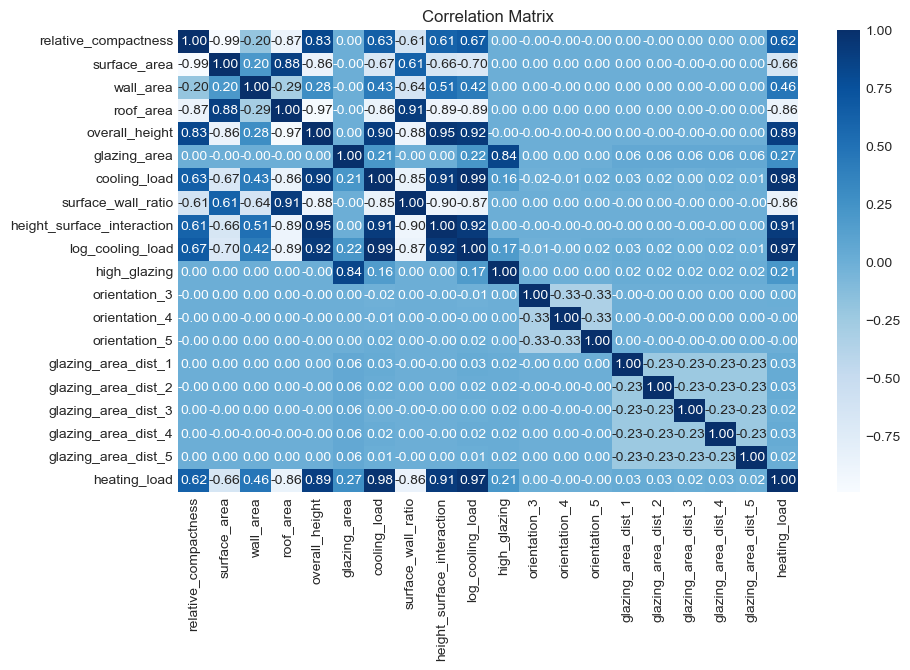

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

In [16]:
print("Correlations with Target (heating load):")
correlations = correlation_matrix['heating_load'].abs().sort_values(ascending=False)
correlations = correlations.drop('heating_load')
correlations

Correlations with Target (heating load):


cooling_load                  0.975862
log_cooling_load              0.972170
height_surface_interaction    0.911079
overall_height                0.889431
roof_area                     0.861828
surface_wall_ratio            0.856432
surface_area                  0.658120
relative_compactness          0.622272
wall_area                     0.455671
glazing_area                  0.269841
high_glazing                  0.207567
glazing_area_dist_1           0.034249
glazing_area_dist_2           0.029882
glazing_area_dist_4           0.027606
glazing_area_dist_3           0.017830
glazing_area_dist_5           0.017803
orientation_3                 0.004207
orientation_4                 0.002708
orientation_5                 0.001823
Name: heating_load, dtype: float64

# 6. Save Final Data

In [17]:
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)


print("Data saved!")
print(f"  X_Train.csv: {X_train.shape[1]} columns (scaled)")

Data saved!
  X_Train.csv: 19 columns (scaled)


### Summary
* Added 4 new features, one-hot encoded 2 existing features, scaled numerical features

##### Features Created:
* surface_wall_ratio
* height_surface_interaction
* log_cooling_load
* high_glazing

##### Processing Applied
* One-hot encoded: orientation and glazing_area_dist
* StandardScaler